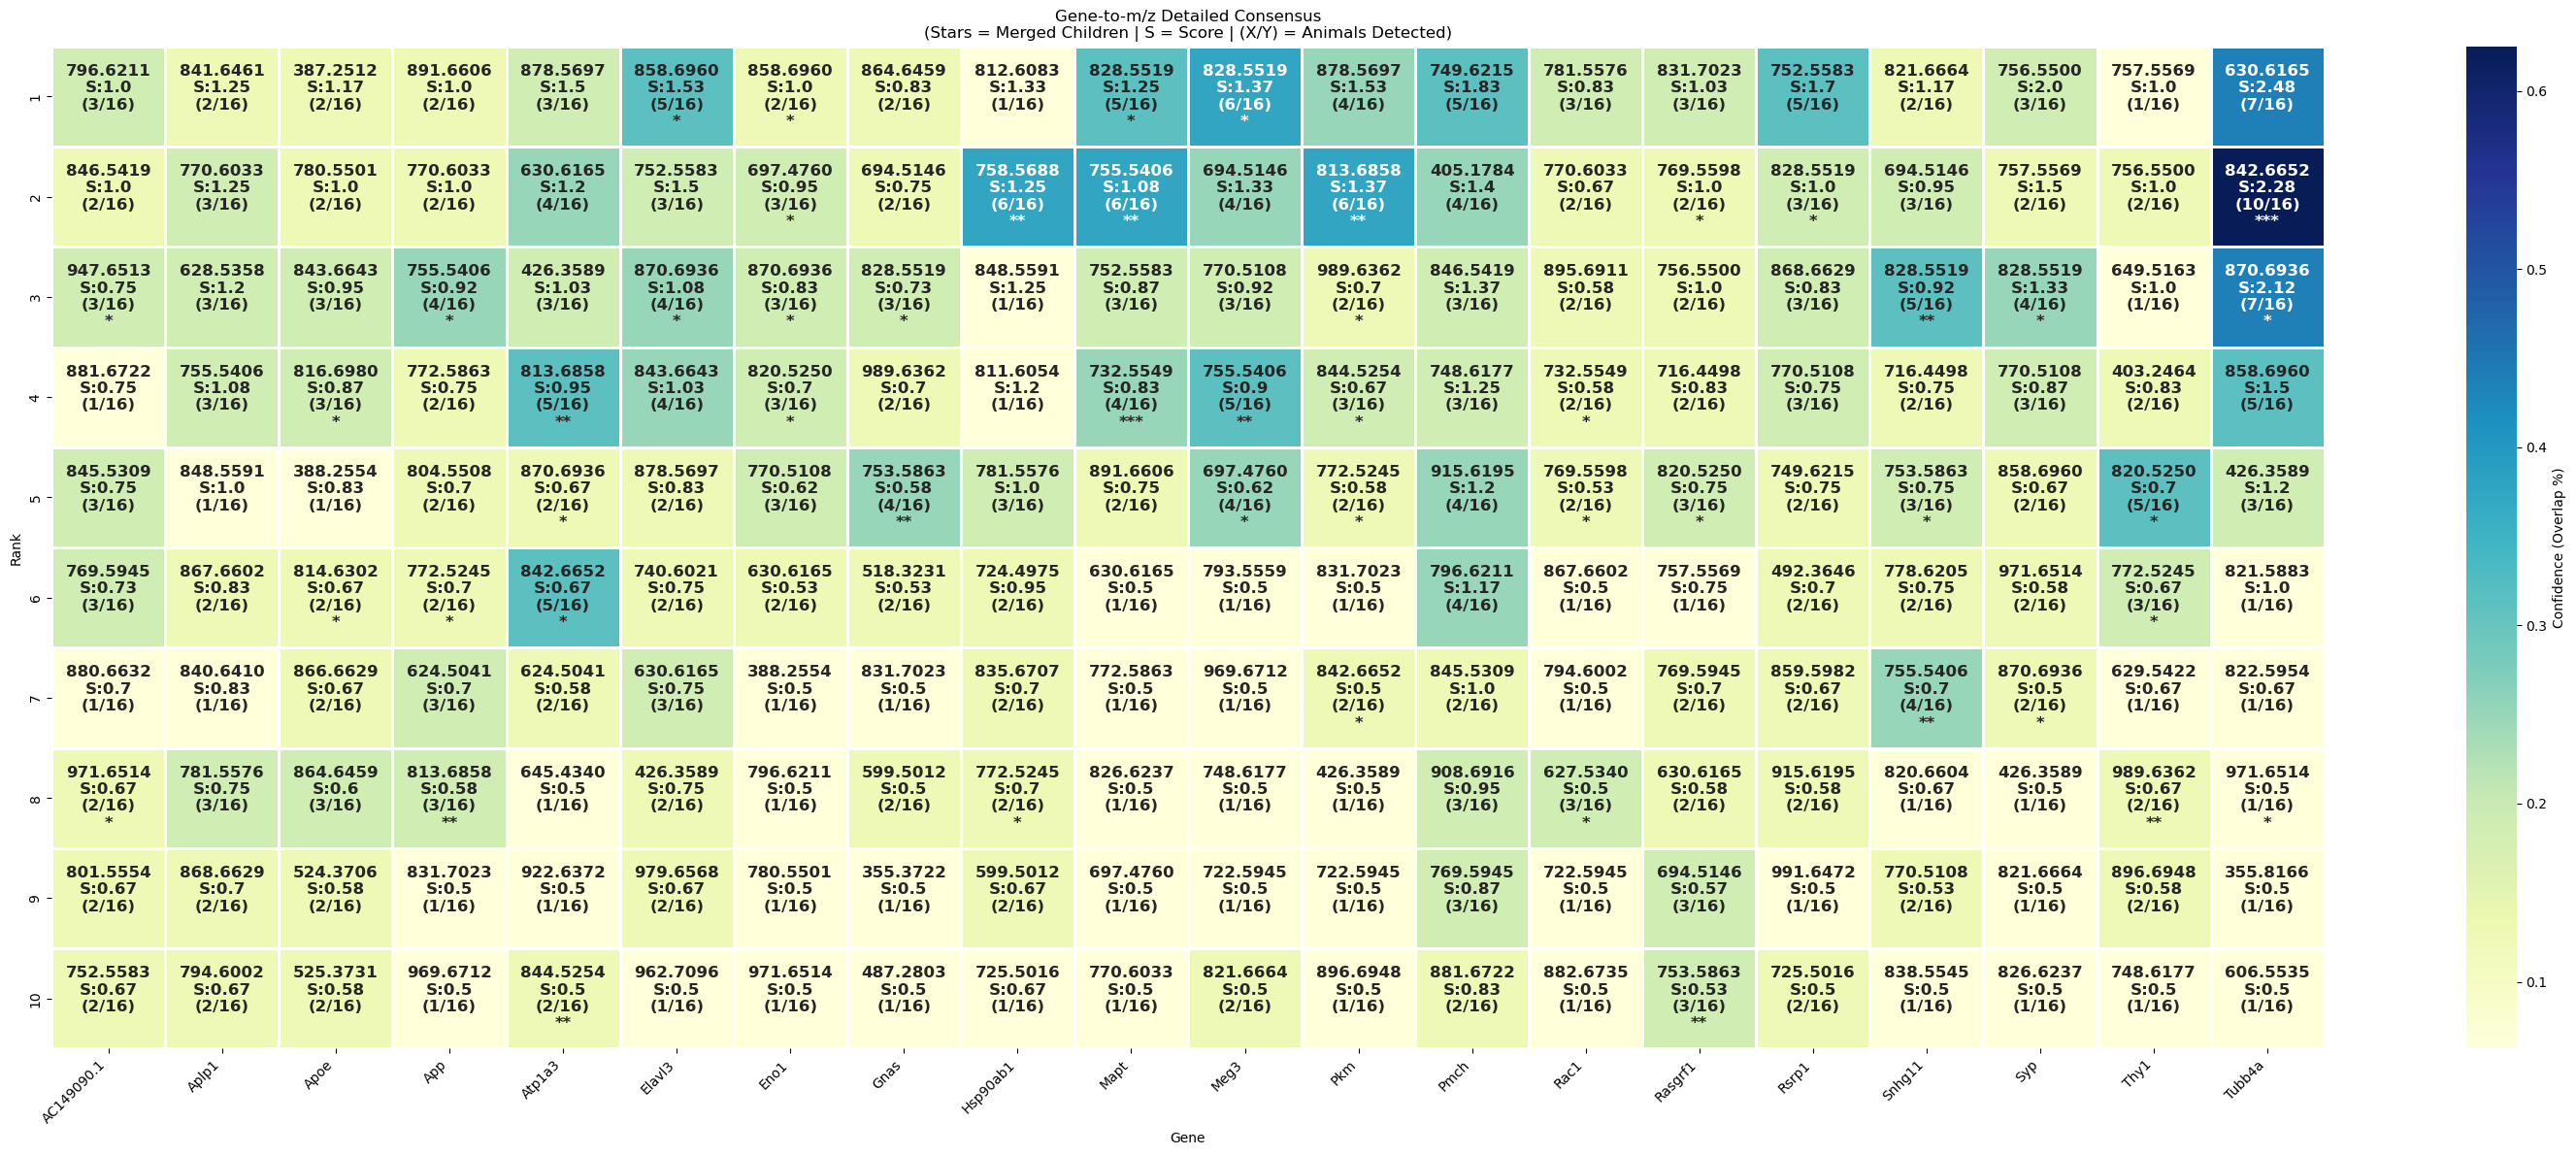

In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '5_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top5_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/parent_children_hierarchy.csv"

K_FACTOR = 1
SYNERGY_WEIGHT = 0.5 
PRECISION = 4  
GROUPS = ['AAD', 'YC', 'AC', 'YAD'] 
TOP_N_RANKS_HEATMAP = 10 

# =============================================================================
# DATA LOADING & HIERARCHY MAPPING
# =============================================================================
def load_hierarchy_maps(path):
    try:
        val_df = pd.read_csv(path)
        pairs = set()
        child_to_parent = {}
        child_cols = [c for c in val_df.columns if 'Child' in c]
        
        for _, row in val_df.iterrows():
            if pd.isna(row['Parent_MZ']): continue
            p_mz = round(float(row['Parent_MZ']), PRECISION)
            row_members = [p_mz]
            
            for col in child_cols:
                if col in row and pd.notna(row[col]) and str(row[col]).strip() != "":
                    c_mz = round(float(row[col]), PRECISION)
                    row_members.append(c_mz)
                    child_to_parent[c_mz] = p_mz 
            
            if len(row_members) > 1:
                for combo in combinations(row_members, 2):
                    pairs.add(frozenset(combo))
        return pairs, child_to_parent
    except Exception as e:
        print(f"Error loading validation: {e}")
        return set(), {}

VALID_PAIRS, CHILD_TO_PARENT = load_hierarchy_maps(VALIDATION_FILE)

def check_relationship(mz1, mz2):
    p = frozenset([round(mz1, PRECISION), round(mz2, PRECISION)])
    return "Validated" if p in VALID_PAIRS else None

def identify_group(sample_name):
    for g in GROUPS:
        if g in sample_name: return g
    return "Other"

# =============================================================================
# CONSENSUS ALGORITHM
# =============================================================================
def calculate_consensus_all(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return []
    
    all_samples = subset['Sample'].unique()
    total_samples_overall = len(all_samples)
    
    mz_data = {} 
    for _, row in subset.iterrows():
        mz = round(row['MZ_Feature'], PRECISION)
        if mz not in mz_data:
            mz_data[mz] = {'samples': set(), 'rrf_score': 0.0, 'child_count': 0}
        mz_data[mz]['samples'].add(row['Sample'])
        mz_data[mz]['rrf_score'] += 1.0 / (row['Rank'] + K_FACTOR)

    candidates = list(mz_data.keys())
    to_remove = set()
    for mz in candidates:
        if mz in CHILD_TO_PARENT:
            parent_mz = CHILD_TO_PARENT[mz]
            if parent_mz in mz_data:
                mz_data[parent_mz]['samples'].update(mz_data[mz]['samples'])
                mz_data[parent_mz]['child_count'] += 1
                to_remove.add(mz)

    remaining_candidates = [c for c in candidates if c not in to_remove]
    final_stats = []
    
    for focal_mz in remaining_candidates:
        boosted_score = mz_data[focal_mz]['rrf_score']
        for other_mz in remaining_candidates:
            if focal_mz == other_mz: continue
            if check_relationship(focal_mz, other_mz):
                co_occ = mz_data[focal_mz]['samples'].intersection(mz_data[other_mz]['samples'])
                boosted_score += (len(co_occ) * SYNERGY_WEIGHT)

        final_stats.append({
            'Gene': gene_name, 
            'mz': focal_mz, 
            'final_score': round(boosted_score, 2),
            'found': len(mz_data[focal_mz]['samples']),
            'total': total_samples_overall,
            'confidence_pct': len(mz_data[focal_mz]['samples']) / total_samples_overall,
            'stars': mz_data[focal_mz]['child_count']
        })

    # Sort so the highest score is Rank 1
    final_stats.sort(key=lambda x: x['final_score'], reverse=True)
    return final_stats

# =============================================================================
# DATA PROCESSING & FIXING THE KEYERROR
# =============================================================================
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)
except FileNotFoundError:
    print(f"File {INPUT_FILE} not found.")
    exit()

heatmap_data = []
unique_genes = df['Gene'].unique()

for gene in unique_genes:
    ranked_list = calculate_consensus_all(df, gene)
    # Correctly adding the 'Rank' key back to the dictionary
    for i, cand in enumerate(ranked_list[:TOP_N_RANKS_HEATMAP]):
        cand['Rank'] = i + 1  # This fixes the KeyError: 'Rank'
        heatmap_data.append(cand)

# =============================================================================
# PLOTTING
# =============================================================================
if heatmap_data:
    h_df = pd.DataFrame(heatmap_data)
    
    # Using 'confidence_pct' to match the key in calculate_consensus_all
    conf_matrix = h_df.pivot(index='Rank', columns='Gene', values='confidence_pct')
    
    def format_label(row):
        stars = '*' * int(row['stars'])
        return f"{row['mz']:.4f}\nS:{row['final_score']}\n({int(row['found'])}/{int(row['total'])})\n{stars}"
    
    h_df['Label'] = h_df.apply(format_label, axis=1)
    label_matrix = h_df.pivot(index='Rank', columns='Gene', values='Label')

    plt.figure(figsize=(max(14, len(unique_genes) * 1.5), TOP_N_RANKS_HEATMAP * 1.2))

    sns.heatmap(conf_matrix, annot=label_matrix, fmt="", cmap="YlGnBu", 
                cbar_kws={'label': 'Confidence (Overlap %)'},
                linewidths=1.0, 
                annot_kws={"size": 12, "weight": "bold"})
    
    plt.title("Gene-to-m/z Detailed Consensus\n(Stars = Merged Children | S = Score | (X/Y) = Animals Detected)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No heatmap data to display.")

In [11]:
import pandas as pd
import numpy as np
from itertools import combinations

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '5_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top5_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/parent_children_hierarchy.csv"

K_FACTOR = 1
SYNERGY_WEIGHT = 0.5 
PRECISION = 4  
TOP_N_RANKS = 10 

# =============================================================================
# DATA LOADING & HIERARCHY MAPPING
# =============================================================================
def load_hierarchy_maps(path):
    try:
        val_df = pd.read_csv(path)
        pairs = set()
        child_to_parent = {}
        child_cols = [c for c in val_df.columns if 'Child' in c]
        
        for _, row in val_df.iterrows():
            if pd.isna(row['Parent_MZ']): continue
            p_mz = round(float(row['Parent_MZ']), PRECISION)
            row_members = [p_mz]
            
            for col in child_cols:
                if col in row and pd.notna(row[col]) and str(row[col]).strip() != "":
                    c_mz = round(float(row[col]), PRECISION)
                    row_members.append(c_mz)
                    child_to_parent[c_mz] = p_mz 
            
            if len(row_members) > 1:
                for combo in combinations(row_members, 2):
                    pairs.add(frozenset(combo))
        return pairs, child_to_parent
    except Exception as e:
        print(f"Error loading validation: {e}")
        return set(), {}

VALID_PAIRS, CHILD_TO_PARENT = load_hierarchy_maps(VALIDATION_FILE)

# =============================================================================
# CONSENSUS ALGORITHM
# =============================================================================
def calculate_consensus_with_samples(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return []
    
    all_samples = subset['Sample'].unique()
    total_samples_overall = len(all_samples)
    
    mz_data = {} 
    for _, row in subset.iterrows():
        mz = round(row['MZ_Feature'], PRECISION)
        if mz not in mz_data:
            mz_data[mz] = {
                'samples': set(), 
                'rrf_score': 0.0, 
                'children_info': {} 
            }
        mz_data[mz]['samples'].add(row['Sample'])
        mz_data[mz]['rrf_score'] += 1.0 / (row['Rank'] + K_FACTOR)

    candidates = list(mz_data.keys())
    to_remove = set()
    parent_only_samples = {mz: list(mz_data[mz]['samples']) for mz in candidates}

    for mz in candidates:
        if mz in CHILD_TO_PARENT:
            parent_mz = CHILD_TO_PARENT[mz]
            if parent_mz in mz_data:
                mz_data[parent_mz]['children_info'][mz] = list(mz_data[mz]['samples'])
                mz_data[parent_mz]['samples'].update(mz_data[mz]['samples'])
                to_remove.add(mz)

    remaining_candidates = [c for c in candidates if c not in to_remove]
    final_stats = []
    
    for focal_mz in remaining_candidates:
        boosted_score = mz_data[focal_mz]['rrf_score']
        for other_mz in remaining_candidates:
            if focal_mz == other_mz: continue
            if frozenset([focal_mz, other_mz]) in VALID_PAIRS:
                co_occ = mz_data[focal_mz]['samples'].intersection(mz_data[other_mz]['samples'])
                boosted_score += (len(co_occ) * SYNERGY_WEIGHT)

        child_details = [f"{c_mz} ({', '.join(samps)})" for c_mz, samps in mz_data[focal_mz]['children_info'].items()]
        
        final_stats.append({
            'Gene': gene_name, 
            'Rank': 0, # Placeholder
            'Parent_MZ': focal_mz, 
            'Final_Score': round(boosted_score, 2),
            'Sample_Count': len(mz_data[focal_mz]['samples']),
            'Parent_Samples': ", ".join(parent_only_samples[focal_mz]),
            'Participating_Children': " | ".join(child_details) if child_details else "None"
        })

    final_stats.sort(key=lambda x: x['Final_Score'], reverse=True)
    return final_stats

# =============================================================================
# EXECUTION
# =============================================================================
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)

    all_data = []
    for gene in df['Gene'].unique():
        results = calculate_consensus_with_samples(df, gene)
        for i, item in enumerate(results[:TOP_N_RANKS]):
            item['Rank'] = i + 1
            all_data.append(item)

    summary_df = pd.DataFrame(all_data)
    
    # Updated column list to include 'Sample_Count'
    cols = ['Gene', 'Rank', 'Parent_MZ', 'Final_Score', 'Sample_Count', 'Parent_Samples', 'Participating_Children']
    
    # Print list to console
    print(summary_df[cols].to_string(index=False))

    # Export
    summary_df[cols].to_csv("5_gene_to_mz_synced_results_v1_analytic_fast/gene_consensus_detailed_samples.csv", index=False)
    print(f"\n[Success] Detailed list with sample counts saved to 'gene_consensus_detailed_samples.csv'")

except Exception as e:
    print(f"Error: {e}")

      Gene  Rank  Parent_MZ  Final_Score  Sample_Count                                       Parent_Samples                                                                         Participating_Children
AC149090.1     1   796.6211         1.00             3                                   YAD_3, YC_1, AAD_3                                                                                           None
AC149090.1     2   846.5419         1.00             2                                         YAD_1, YAD_4                                                                                           None
AC149090.1     3   947.6513         0.75             3                                  AAD_4, YAD_4, AAD_2                                                                               948.6564 (AAD_2)
AC149090.1     4   881.6722         0.75             1                                                 AC_3                                                                                 